# 04 Train Baseline LSTM Model Notebook

This notebook trains the first baseline ASL sign recognition model using the cleaned WLASL100 MediaPipe keypoint dataset. The model uses a BiLSTM architecture to learn movement patterns from landmark sequences and classify each sample into one of 100 ASL glosses.

## Import Libraries

In [11]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tqdm.auto import tqdm
from sklearn.metrics import f1_score
import time
import torch.nn.functional as F

e:\Be_My_Ear\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set seed and paths

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path("E:/Be_My_Ear")

BASE_DIR = PROJECT_ROOT / "data" / "processed" / "ASL" / "WLASL100"
CLEAN_INDEX_FILE = BASE_DIR / "wlasl100_clean_keypoint_index.csv"
LABEL_MAP_FILE = PROJECT_ROOT / "data" / "label_maps" / "asl_wlasl100_labels.json"

MODEL_DIR = PROJECT_ROOT / "models" / "ASL" / "WLASL100"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "baseline_bilstm_wlasl100.pt"

print("Clean index exists:", CLEAN_INDEX_FILE.exists())
print("Label map exists:", LABEL_MAP_FILE.exists())
print("Model will save to:", MODEL_PATH)

Clean index exists: True
Label map exists: True
Model will save to: E:\Be_My_Ear\models\ASL\baseline_bilstm_wlasl100.pt


## Load dataset index

In [3]:
df = pd.read_csv(CLEAN_INDEX_FILE)

print("Total samples:", len(df))
print("Total classes:", df["label_id"].nunique())
print("Input file example:", df.iloc[0]["keypoint_path"])

df.head()

Total samples: 1013
Total classes: 100
Input file example: E:\Be_My_Ear\data\processed\ASL\WLASL100\keypoints\69422.npy


,video_id,gloss,label_id,original_class_id,video_path,keypoint_path,zero_ratio
0,69422,orange,67,27,E:\Be_My_Ear\data\raw\ASL\videos\69422.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.321512
1,10898,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10898.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.126163
2,10893,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10893.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.264535
3,10892,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10892.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.170930
4,10895,city,20,82,E:\Be_My_Ear\data\raw\ASL\videos\10895.mp4,E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,0.464341


## Create train, validation, test split

Because some classes only have 5 samples, I use a manual class-balanced split.

In [4]:
train_records = []
val_records = []
test_records = []

for label_id, group in df.groupby("label_id"):
    group = group.sample(frac=1, random_state=SEED).reset_index(drop=True)

    n = len(group)

    n_test = max(1, int(round(n * 0.15)))
    n_val = max(1, int(round(n * 0.15)))

    test_part = group.iloc[:n_test]
    val_part = group.iloc[n_test:n_test + n_val]
    train_part = group.iloc[n_test + n_val:]

    train_records.append(train_part)
    val_records.append(val_part)
    test_records.append(test_part)

train_df = pd.concat(train_records).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat(val_records).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(test_records).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("Train classes:", train_df["label_id"].nunique())
print("Validation classes:", val_df["label_id"].nunique())
print("Test classes:", test_df["label_id"].nunique())

Train samples: 697
Validation samples: 158
Test samples: 158
Train classes: 100
Validation classes: 100
Test classes: 100


## PyTorch Dataset

In [13]:
class SignKeypointDataset(Dataset):
    def __init__(self, dataframe, normalize=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.normalize = normalize

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        keypoints = np.load(row["keypoint_path"]).astype(np.float32)

        if self.normalize:
            mean = keypoints.mean(axis=0, keepdims=True)
            std = keypoints.std(axis=0, keepdims=True)
            keypoints = (keypoints - mean) / (std + 1e-6)

        label = int(row["label_id"])

        keypoints = torch.tensor(keypoints, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return keypoints, label

## Create Dataloaders

In [14]:
BATCH_SIZE = 32

train_dataset = SignKeypointDataset(train_df, normalize=True)
val_dataset = SignKeypointDataset(val_df, normalize=True)
test_dataset = SignKeypointDataset(test_df, normalize=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", x_batch.shape)
print("Label batch shape:", y_batch.shape)
print("Example labels:", y_batch[:10])

Input batch shape: torch.Size([32, 60, 258])
Label batch shape: torch.Size([32])
Example labels: tensor([76, 96, 94, 54, 37, 51, 49,  2, 56, 25])


## Implement model

### Build BiLSTM model

In [15]:
class SignBiLSTM(nn.Module):
    def __init__(self, input_size=258, hidden_size=256, num_classes=100, num_layers=2, dropout=0.3):
        super(SignBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        logits = self.classifier(last_output)
        return logits

### Set device, model, loss, optimiser

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NUM_CLASSES = df["label_id"].nunique()

model = SignBiLSTM(
    input_size=258,
    hidden_size=256,
    num_classes=NUM_CLASSES,
    num_layers=2,
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Class-weighted loss helps with uneven samples per class
class_counts = train_df["label_id"].value_counts().sort_index()

weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float32)
weights = weights / weights.sum() * len(weights)
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

print(model)

Using device: cpu
SignBiLSTM(
  (lstm): LSTM(258, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)


In [17]:
def top_k_accuracy(outputs, labels, k=5):
    _, top_k_preds = outputs.topk(k, dim=1)
    correct = top_k_preds.eq(labels.view(-1, 1).expand_as(top_k_preds))
    return correct.any(dim=1).float().mean().item()

### Training and evaluation functions

In [18]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs):
    model.train()

    total_loss = 0
    total_top1 = 0
    total_top5 = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{total_epochs} [Training]",
        leave=False
    )

    for step, (x, y) in enumerate(progress_bar, start=1):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        batch_top1 = (preds == y).float().mean().item()
        batch_top5 = top_k_accuracy(outputs, y, k=5)

        total_loss += loss.item()
        total_top1 += batch_top1
        total_top5 += batch_top5

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

        progress_bar.set_postfix({
            "step": f"{step}/{len(loader)}",
            "loss": f"{loss.item():.4f}",
            "top1": f"{batch_top1:.4f}",
            "top5": f"{batch_top5:.4f}"
        })

    avg_loss = total_loss / len(loader)
    avg_top1 = total_top1 / len(loader)
    avg_top5 = total_top5 / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, avg_top1, avg_top5, macro_f1


def evaluate(model, loader, criterion, device, epoch, total_epochs):
    model.eval()

    total_loss = 0
    total_top1 = 0
    total_top5 = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(
        loader,
        desc=f"Epoch {epoch}/{total_epochs} [Validation]",
        leave=False
    )

    with torch.no_grad():
        for step, (x, y) in enumerate(progress_bar, start=1):
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            preds = torch.argmax(outputs, dim=1)

            batch_top1 = (preds == y).float().mean().item()
            batch_top5 = top_k_accuracy(outputs, y, k=5)

            total_loss += loss.item()
            total_top1 += batch_top1
            total_top5 += batch_top5

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            progress_bar.set_postfix({
                "step": f"{step}/{len(loader)}",
                "loss": f"{loss.item():.4f}",
                "top1": f"{batch_top1:.4f}",
                "top5": f"{batch_top5:.4f}"
            })

    avg_loss = total_loss / len(loader)
    avg_top1 = total_top1 / len(loader)
    avg_top5 = total_top5 / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, avg_top1, avg_top5, macro_f1

### Train Model

Initial with 40 epoch then increase

In [19]:
EPOCHS = 40

history = {
    "train_loss": [],
    "train_top1": [],
    "train_top5": [],
    "train_f1": [],
    "val_loss": [],
    "val_top1": [],
    "val_top5": [],
    "val_f1": []
}

best_val_f1 = 0.0
best_val_top5 = 0.0

print("=" * 70)
print("Be My Ear - ASL WLASL100 Baseline Training")
print("=" * 70)
print(f"Device: {device}")
print(f"Model: BiLSTM")
print(f"Input shape: (60, 258)")
print(f"Classes: {NUM_CLASSES}")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Model save path: {MODEL_PATH}")
print("=" * 70)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 70)

    train_loss, train_top1, train_top5, train_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device, epoch, EPOCHS
    )

    val_loss, val_top1, val_top5, val_f1 = evaluate(
        model, val_loader, criterion, device, epoch, EPOCHS
    )

    history["train_loss"].append(train_loss)
    history["train_top1"].append(train_top1)
    history["train_top5"].append(train_top5)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_top1"].append(val_top1)
    history["val_top5"].append(val_top5)
    history["val_f1"].append(val_f1)

    improved = val_f1 > best_val_f1

    if improved:
        best_val_f1 = val_f1
        best_val_top5 = val_top5

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_f1": best_val_f1,
            "best_val_top5": best_val_top5,
            "num_classes": NUM_CLASSES,
            "input_size": 258,
            "sequence_length": 60
        }, MODEL_PATH)

        save_status = "Saved new best model"
    else:
        save_status = "No improvement"

    print(
        f"Train | Loss: {train_loss:.4f} | Top-1: {train_top1:.4f} | "
        f"Top-5: {train_top5:.4f} | F1: {train_f1:.4f}"
    )

    print(
        f"Val   | Loss: {val_loss:.4f} | Top-1: {val_top1:.4f} | "
        f"Top-5: {val_top5:.4f} | F1: {val_f1:.4f}"
    )

    print(f"Status: {save_status}")
    print(f"Best Val F1 so far: {best_val_f1:.4f}")
    print(f"Best Val Top-5 so far: {best_val_top5:.4f}")

end_time = time.time()
training_minutes = (end_time - start_time) / 60

print("\n" + "=" * 70)
print("Training completed")
print("=" * 70)
print(f"Total training time: {training_minutes:.2f} minutes")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Best validation Top-5: {best_val_top5:.4f}")
print(f"Best model saved to: {MODEL_PATH}")
print("=" * 70)

Be My Ear - ASL WLASL100 Baseline Training
Device: cpu
Model: BiLSTM
Input shape: (60, 258)
Classes: 100
Train samples: 697
Validation samples: 158
Test samples: 158
Epochs: 40
Batch size: 32
Model save path: E:\Be_My_Ear\models\ASL\baseline_bilstm_wlasl100.pt

Epoch 1/40
----------------------------------------------------------------------


e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of t

Train | Loss: 4.6194 | Top-1: 0.0061 | Top-5: 0.0430 | F1: 0.0053
Val   | Loss: 4.5920 | Top-1: 0.0125 | Top-5: 0.0758 | F1: 0.0009
Status: Saved new best model
Best Val F1 so far: 0.0009
Best Val Top-5 so far: 0.0758

Epoch 2/40
----------------------------------------------------------------------


e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of t

Train | Loss: 4.5014 | Top-1: 0.0284 | Top-5: 0.1159 | F1: 0.0213
Val   | Loss: 4.3496 | Top-1: 0.0129 | Top-5: 0.0946 | F1: 0.0018
Status: Saved new best model
Best Val F1 so far: 0.0018
Best Val Top-5 so far: 0.0946

Epoch 3/40
----------------------------------------------------------------------


...

Train | Loss: 0.0363 | Top-1: 0.9939 | Top-5: 1.0000 | F1: 0.9951
Val   | Loss: 8.9751 | Top-1: 0.0821 | Top-5: 0.2467 | F1: 0.0725
Status: No improvement
Best Val F1 so far: 0.0962
Best Val Top-5 so far: 0.2592

Epoch 39/40
----------------------------------------------------------------------


e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of t

Train | Loss: 0.0304 | Top-1: 0.9929 | Top-5: 1.0000 | F1: 0.9943
Val   | Loss: 9.1110 | Top-1: 0.1008 | Top-5: 0.2783 | F1: 0.0915
Status: No improvement
Best Val F1 so far: 0.0962
Best Val Top-5 so far: 0.2592

Epoch 40/40
----------------------------------------------------------------------


Train | Loss: 0.0357 | Top-1: 0.9886 | Top-5: 1.0000 | F1: 0.9904
Val   | Loss: 9.1727 | Top-1: 0.0942 | Top-5: 0.2658 | F1: 0.0879
Status: No improvement
Best Val F1 so far: 0.0962
Best Val Top-5 so far: 0.2592

Training completed
Total training time: 2.90 minutes
Best validation F1: 0.0962
Best validation Top-5: 0.2592
Best model saved to: E:\Be_My_Ear\models\ASL\baseline_bilstm_wlasl100.pt


e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of t

## Evaluate Performance

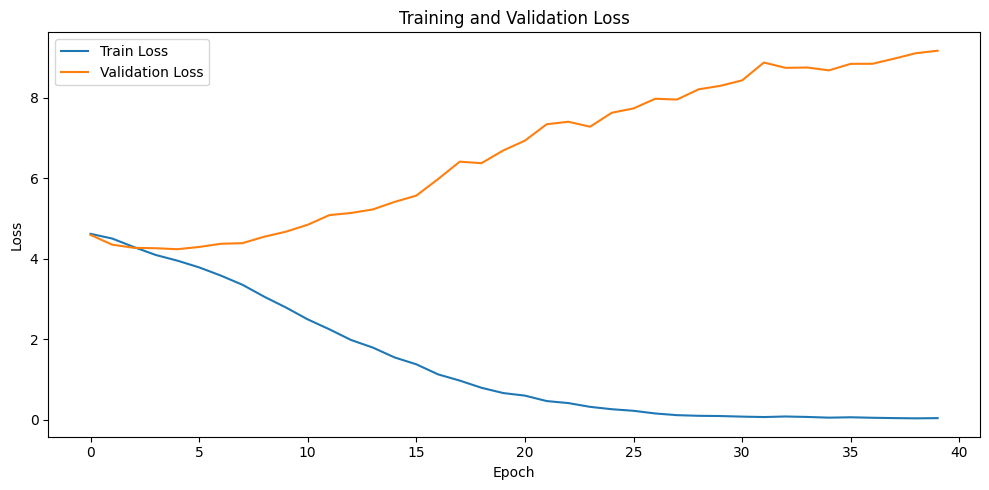

In [20]:
# Plot training curves

plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

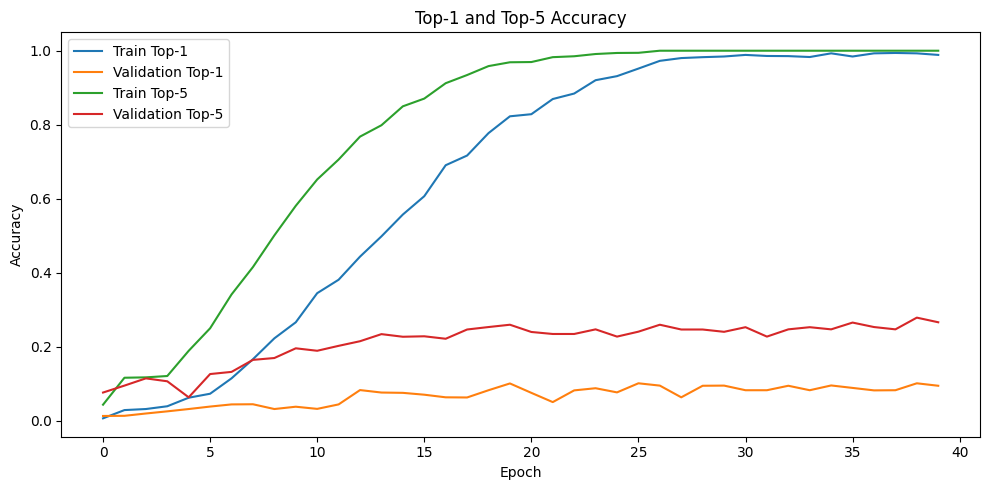

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_top1"], label="Train Top-1")
plt.plot(history["val_top1"], label="Validation Top-1")
plt.plot(history["train_top5"], label="Train Top-5")
plt.plot(history["val_top5"], label="Validation Top-5")
plt.title("Top-1 and Top-5 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

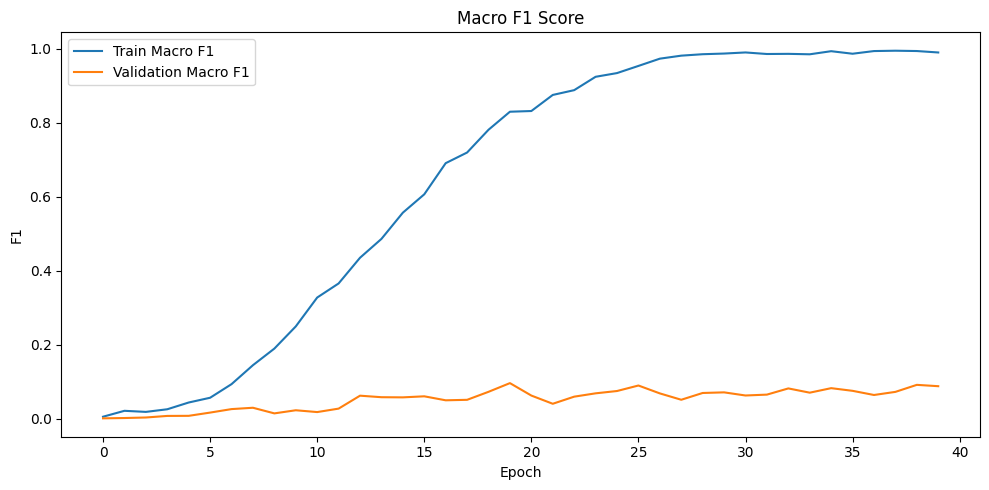

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_f1"], label="Train Macro F1")
plt.plot(history["val_f1"], label="Validation Macro F1")
plt.title("Macro F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.show()

### Load best model checkpoint before test evaluation

In [23]:
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded best model from epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])
print("Best validation Top-5:", checkpoint["best_val_top5"])

Loaded best model from epoch: 20
Best validation F1: 0.09619047619047617
Best validation Top-5: 0.25916666686534884


In [24]:
def collect_predictions(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Collecting predictions"):
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [25]:
y_true, y_pred, y_probs = collect_predictions(model, test_loader, device)

test_top1 = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

# Top-5 test accuracy
top5_correct = 0
for true_label, prob in zip(y_true, y_probs):
    top5_preds = np.argsort(prob)[-5:]
    if true_label in top5_preds:
        top5_correct += 1

test_top5 = top5_correct / len(y_true)

print("=" * 70)
print("Test Set Evaluation")
print("=" * 70)
print(f"Test Top-1 Accuracy: {test_top1:.4f}")
print(f"Test Top-5 Accuracy: {test_top5:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print("=" * 70)

Test Set Evaluation
Test Top-1 Accuracy: 0.0696
Test Top-5 Accuracy: 0.2342
Test Macro F1: 0.0612



e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
e:\Be_My_Ear\.venv\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 

In [26]:
# Save training history

history_df = pd.DataFrame(history)
HISTORY_FILE = MODEL_DIR / "baseline_bilstm_wlasl100_history.csv"

history_df.to_csv(HISTORY_FILE, index=False)

print("Saved training history to:")
print(HISTORY_FILE)

history_df.head()

Saved training history to:
E:\Be_My_Ear\models\ASL\baseline_bilstm_wlasl100_history.csv


,train_loss,train_top1,train_top5,train_f1,val_loss,val_top1,val_top5,val_f1
0,4.619437,0.006080,0.043011,0.005303,4.592021,0.012500,0.075833,0.000930
1,4.501376,0.028409,0.115852,0.021299,4.349558,0.012917,0.094583,0.001779
2,4.289647,0.031250,0.116875,0.018373,4.271069,0.019167,0.114167,0.003211
3,4.093732,0.038750,0.120511,0.025483,4.260766,0.025000,0.106250,0.007468
4,3.951812,0.061875,0.188693,0.043750,4.236517,0.031250,0.062917,0.007718


### Show a few prediction examples with label map

In [27]:
with open(LABEL_MAP_FILE, "r", encoding="utf-8") as f:
    label_map = json.load(f)

test_examples = test_df.reset_index(drop=True).copy()

example_rows = []

for i in range(min(10, len(test_examples))):
    true_id = int(y_true[i])
    pred_id = int(y_pred[i])
    confidence = float(y_probs[i][pred_id])

    example_rows.append({
        "video_id": test_examples.iloc[i]["video_id"],
        "true_gloss": label_map[str(true_id)]["gloss"] if str(true_id) in label_map else true_id,
        "predicted_gloss": label_map[str(pred_id)]["gloss"] if str(pred_id) in label_map else pred_id,
        "confidence": round(confidence, 4)
    })

pd.DataFrame(example_rows)

,video_id,true_gloss,predicted_gloss,confidence
0,56557,table,cousin,0.4903
1,69290,dark,graduate,0.8029
2,57639,thanksgiving,candy,0.2454
3,64280,yes,mother,0.4831
4,33273,like,pizza,0.3094
5,10157,cheat,cool,0.4392
6,35452,medicine,what,0.2713
7,36930,mother,drink,0.1894
8,34831,many,help,0.6080
9,62160,walk,city,0.6208


In [28]:
print("Final training summary")
print("----------------------")
print(f"Dataset: WLASL100")
print(f"Clean samples: {len(df)}")
print(f"Classes: {NUM_CLASSES}")
print(f"Model: BiLSTM")
print(f"Input shape: (60, 258)")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Best validation Top-5: {best_val_top5:.4f}")
print(f"Test Top-1 Accuracy: {test_top1:.4f}")
print(f"Test Top-5 Accuracy: {test_top5:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")
print(f"Model saved to: {MODEL_PATH}")

Final training summary
----------------------
Dataset: WLASL100
Clean samples: 1013
Classes: 100
Model: BiLSTM
Input shape: (60, 258)
Best validation F1: 0.0962
Best validation Top-5: 0.2592
Test Top-1 Accuracy: 0.0696
Test Top-5 Accuracy: 0.2342
Test Macro F1: 0.0612
Model saved to: E:\Be_My_Ear\models\ASL\baseline_bilstm_wlasl100.pt
